In [1]:
from langchain_groq import ChatGroq
import os

os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
model = ChatGroq( model= "qwen/qwen3-32b")

In [6]:
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(
    max_results=5,
    topic="general",

)
tavily_tool.invoke("what is the current price of bitcoin?")

{'query': 'what is the current price of bitcoin?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.coindesk.com/price/bitcoin',
   'title': 'Bitcoin price today, BTC to USD live price, marketcap and chart',
   'content': 'The price of Bitcoin (BTC) is $69333.79 today as of Mar 26, 2026, 9:33 am EDT, with a 24-hour trading volume of $16.54B.',
   'score': 0.8991304,
   'raw_content': None},
  {'url': 'https://www.tradingview.com/symbols/BTCUSD/',
   'title': 'BTC USD — Bitcoin Price and Chart - TradingView',
   'content': 'The current price of Bitcoin (BTC) is 69,611 USD — it has risen 0.41% in ... The current market capitalization of Bitcoin (BTC) is \u202a1.39 T\u202c USD. To see',
   'score': 0.898277,
   'raw_content': None},
  {'url': 'https://coinmarketcap.com/currencies/bitcoin/',
   'title': 'Bitcoin price today, BTC to USD live price, marketcap and chart',
   'content': 'The live Bitcoin price today is $69,637.58 USD with a 24-hou

In [12]:
tool

<function langchain_core.tools.convert.tool(name_or_callable: str | collections.abc.Callable | None = None, runnable: langchain_core.runnables.base.Runnable | None = None, *args: Any, description: str | None = None, return_direct: bool = False, args_schema: type[pydantic.main.BaseModel] | dict[str, typing.Any] | None = None, infer_schema: bool = True, response_format: Literal['content', 'content_and_artifact'] = 'content', parse_docstring: bool = False, error_on_invalid_docstring: bool = True, extras: dict[str, typing.Any] | None = None) -> langchain_core.tools.base.BaseTool | collections.abc.Callable[[collections.abc.Callable | langchain_core.runnables.base.Runnable], langchain_core.tools.base.BaseTool]>

In [11]:
from langchain.tools import tool
@tool("calculator", description="Performs arithmetic calculations. Use this for any math problems.")
def calc(expression: str) -> str:
    """Evaluate mathematical expressions."""
    return str(eval(expression))

In [13]:
from langchain.agents import create_agent

agent = create_agent(
    model = model,
    tools = [tavily_tool,calc]
)

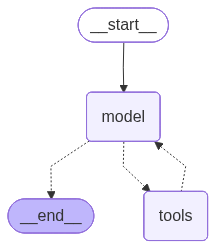

In [14]:
agent

In [15]:
user_input = "What is the currentAI news for Antropic and then calculate 5 + 5"
for step in agent.stream(
    {"messages": user_input},
    stream_mode="values"
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

What is the currentAI news for Antropic and then calculate 5 + 5
================================== Ai Message ==================================
Tool Calls:
  tavily_search (dhny5cmev)
 Call ID: dhny5cmev
  Args:
    query: current AI news for Antropic
    time_range: day
    topic: general
  calculator (e5pj66tqa)
 Call ID: e5pj66tqa
  Args:
    expression: 5 + 5
================================= Tool Message =================================
Name: calculator

10
================================== Ai Message ==================================

Here's the information you requested:

**Current AI News for Anthropic (Last 24 hours):**
1. **Claude's Computer-Using AI Agent** - Anthropic expanded Claude's capabilities with a new "computer use" feature enabling autonomous task completion (BitBiased, 0.67 score).
2. **Rate Limit Concerns** - Users are urging Anthropic to address API rate limit issues before ro